# Linear Regression

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pandas as pd 
import numpy as np

input_file_path_new = "D:\\final_year_project\\final_export\\csv\\new\\training_parameters_postprocessing_new.csv"
df = pd.read_csv(input_file_path_new)

# Define features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1].values.reshape(-1, 1)   # The last column
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).flatten()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
# Train the Linear Regression model
model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

# Predict on the test set
y_pred = model_scaled.predict(X_test)

#np.set_printoptions(precision=2, suppress=True)  # Set precision and avoid scientific notation for small values

# Print model coefficients and intercept
print("Coefficients:", model_scaled.coef_)
print("Intercept:", model_scaled.intercept_)

# Compute R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", round(r2, 4))  # Round to 4 decimal places

Coefficients: [ 3.79975663e-01 -1.63664625e-01 -1.29616702e-01  1.03969435e-03
  1.64978214e+00 -1.58879013e+00 -1.23340696e-01 -7.06682427e-02
  2.09835600e-01 -3.45603219e-02 -3.36744638e-02  3.94439383e-01
  2.46809635e-01 -1.97821503e-02  2.55330829e-01 -6.52967989e-01
  2.17930701e-01 -3.76226208e-01 -1.93239572e-01 -3.98431182e-02]
Intercept: -0.01897884749580713
R² Score: 0.6809
[0.04772669 0.00750718 0.00569379 0.01013448 0.00055929 0.00340467
 0.04552421 0.1        0.07388703 0.00130433 0.00619087 0.00396215
 0.06847041 0.00173668 0.00038703 0.00336052 0.0057887  0.01666593
 0.02793028 0.06533191 0.00068629 0.03410267 0.01762332 0.00655112
 0.01143239 0.02335467 0.00248453 0.01382823 0.00449708 0.00344283
 0.00348936 0.01632799 0.00634999 0.04761518 0.03201529 0.00118165
 0.00754243 0.00070035 0.06935186 0.02781974]


# Actual v/s Linear Model Predicted Wear Rate  

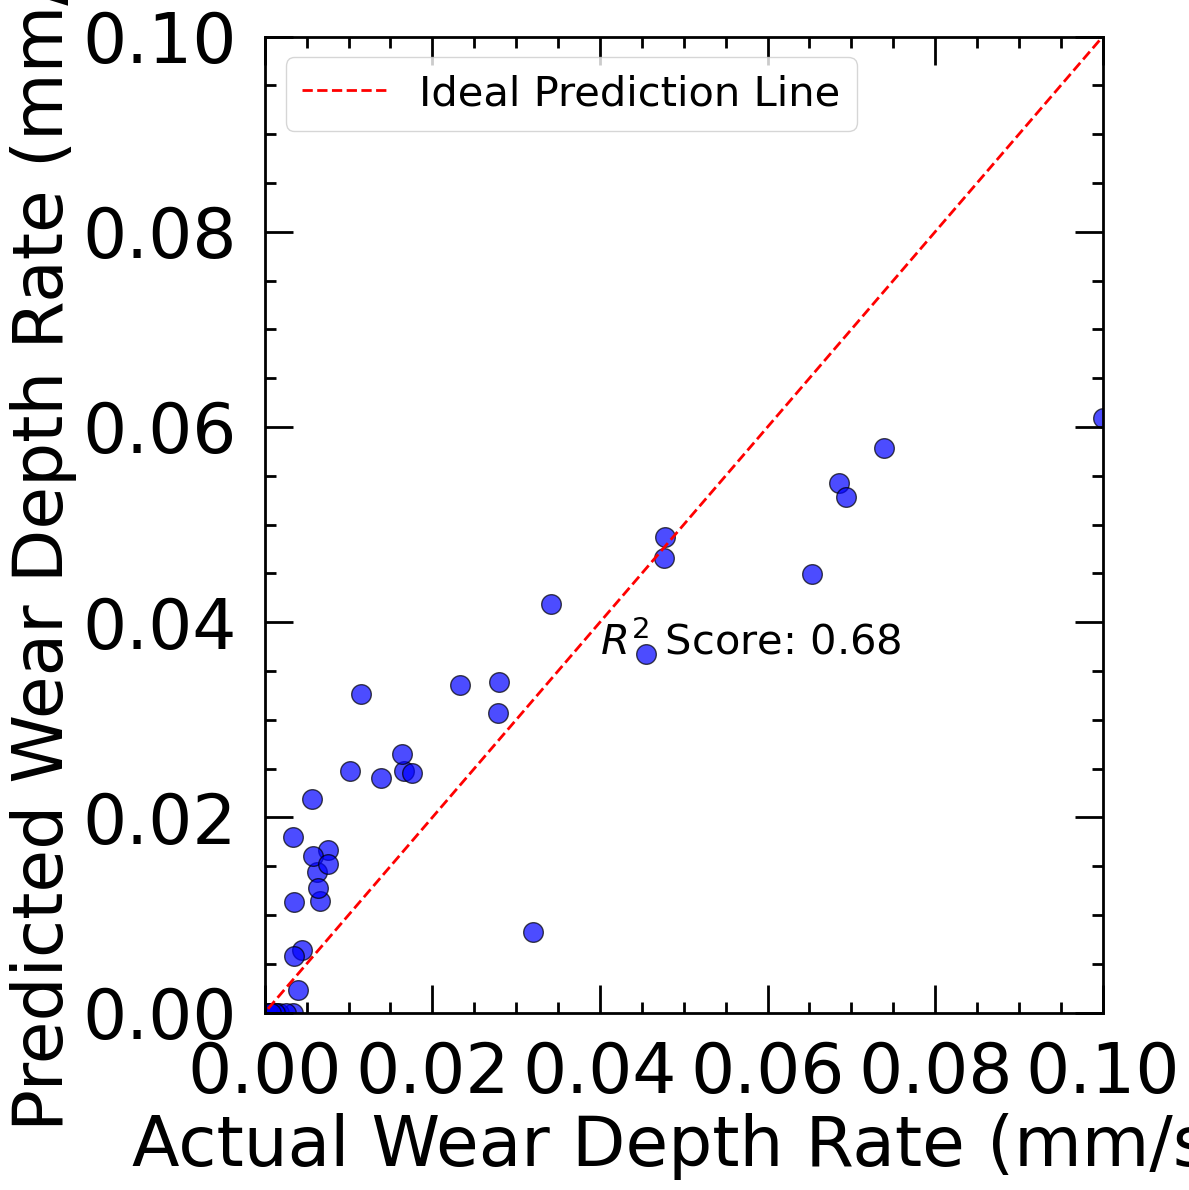

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

y_test_orig = np.clip(scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten(), 0, 0.1)
y_pred_orig = np.clip(scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten(), 0, 0.1)
# Create the Actual vs Predicted plot
fig,ax=plt.subplots(figsize=(12, 12))
for axis in ['top', 'bottom', 'right', 'left']:
    ax.spines[axis].set_linewidth(2)
    ax.spines[axis].set_color('black')

plt.scatter(y_test_orig, y_pred_orig, color='blue', edgecolors='k', alpha=0.7, s=200)  # s controls marker size
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', linewidth=2, label = "Ideal Prediction Line")  # reference line y = x
plt.xlabel("Actual Wear Depth Rate (mm/s)", fontsize=50)
plt.ylabel("Predicted Wear Depth Rate (mm/s)", fontsize=50)
# plt.title("Actual vs Predicted Wear (Linear Regression)", fontsize=16)
# plt.grid(True)
ax.tick_params(direction = 'in',length = 20, axis = 'y',color = 'k',width = 2.0,pad=20, left=True, right=True)
ax.tick_params(direction = 'in',length = 20, axis = 'x',color = 'k',width = 2.0,pad=20,top=True, bottom=True)
ax.tick_params(direction = 'in', which='minor', length=8, color='k', axis = 'x', width = 2.0,top=True, bottom=True)
ax.tick_params(direction = 'in', which='minor', length=8, color='k', axis = 'y', width = 2.0,left=True, right=True)
plt.setp(ax.get_xticklabels(), fontsize = 50, color = 'k')
plt.setp(ax.get_yticklabels(), fontsize = 50, color = 'k')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.locator_params(axis='x', nbins=5)
ax.locator_params(axis='y', nbins=5)

ax.set_xlim(0,.1)
ax.set_ylim(0,.1)


plt.legend(fontsize = 30)
plt.text(0.4, 0.4, r"$R^2$ Score: 0.68", fontsize=30, transform=plt.gca().transAxes, verticalalignment='top')
# output_file_path = "D:\\final_year_project\\final_export\\pics_after_sim\\new_analysis\\actual_vs_predicted_linear.pdf"
# plt.savefig(output_file_path, dpi = 800)
plt.tight_layout()
plt.show()
